# Extended EDA

## Focus Areas:
- More temporal analysis (day-of-week, hour-of-day)
- Market value gap analysis (MMR vs actual selling price)
- Luxury brand premium quantification

Run this to get "car_prices_extended_eda.csv"
- new_features = ['sale_day_of_week', 'sale_day_name', 'sale_hour', 'is_weekend', 
                'sale_month_name', 'price_gap_pct', 'gap_category', 'is_luxury']

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

ModuleNotFoundError: No module named 'numpy.core._exceptions'

ModuleNotFoundError: No module named 'numpy.core._exceptions'

---
## Section 0: Data Loading & Verification

In [2]:
print("="*70)
print("LOADING PREPROCESSED DATA")
print("="*70)

# Load the feature-engineered dataset
df = pd.read_csv('cars_feature_engineered.csv')

print(f"  Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Date range: {df['saledate'].min()} to {df['saledate'].max()}")

print("\n" + "="*70)
print("EXISTING FEATURES")
print("="*70)

print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nTotal columns: {len(df.columns)}")

LOADING PREPROCESSED DATA
  Dataset shape: 472,325 rows × 22 columns
  Date range: 2014-01-01 01:15:00+00:00 to 2015-07-20 19:30:00+00:00

EXISTING FEATURES

Column names:
   1. year
   2. make
   3. model
   4. trim
   5. body
   6. transmission
   7. vin
   8. state
   9. condition
  10. odometer
  11. color
  12. interior
  13. seller
  14. mmr
  15. sellingprice
  16. saledate
  17. price_diff
  18. car_age
  19. mileage_per_year
  20. sale_year
  21. sale_month
  22. sale_day

Total columns: 22


In [3]:
# Quick summary statistics
print("\n" + "="*70)
print("BASIC DATA SUMMARY")
print("="*70)

print("\nNumerical features summary:")
numerical_cols = ['year', 'condition', 'odometer', 'mmr', 'sellingprice', 
                  'car_age', 'mileage_per_year', 'price_diff']
existing_numerical = [col for col in numerical_cols if col in df.columns]

print(df[existing_numerical].describe().round(2))

print("\n" + "-"*70)
print("\nCategorical features:")
categorical_cols = ['make', 'body', 'transmission', 'state', 'seller']
for col in categorical_cols:
    if col in df.columns:
        n_unique = df[col].nunique()
        print(f"  {col:15s}: {n_unique:4d} unique values")


BASIC DATA SUMMARY

Numerical features summary:
            year  condition   odometer        mmr  sellingprice    car_age  \
count  472325.00  472325.00  472325.00  472325.00     472325.00  472325.00   
mean     2010.21      30.77   66701.73   13837.06      13690.51      14.79   
std         3.82      13.29   51939.59    9532.23       9613.03       3.82   
min      1990.00       1.00       1.00      25.00          1.00      10.00   
25%      2008.00      24.00   28137.00    7425.00       7200.00      12.00   
50%      2012.00      35.00   51085.00   12300.00      12200.00      13.00   
75%      2013.00      41.00   96590.00   18300.00      18200.00      17.00   
max      2015.00      49.00  999999.00  182000.00     230000.00      35.00   

       mileage_per_year  price_diff  
count         472325.00   472325.00  
mean            4141.49     -146.55  
std             2519.30     1741.18  
min                0.03   -87750.00  
25%             2253.92     -800.00  
50%             3745

In [4]:
# Preview the data
print("\n" + "="*70)
print("DATA PREVIEW")
print("="*70)

print("\nFirst 5 rows:")
print(df.head())

print("\n" + "-"*70)
print("\nRandom sample of 5 rows:")
print(df.sample(5, random_state=42))


DATA PREVIEW

First 5 rows:
   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    suv    automatic   
1  2015    Kia              Sorento          LX    suv    automatic   
2  2014    BMW             3 Series  328i SULEV  sedan    automatic   
3  2015  Volvo                  S60          T5  sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  sedan    automatic   

                 vin state  condition  odometer  ...  \
0  5xyktca69fg566472    ca        5.0   16639.0  ...   
1  5xyktca69fg561319    ca        5.0    9393.0  ...   
2  wba3c1c51ek116351    ca       45.0    1331.0  ...   
3  yv1612tb4f1310987    ca       41.0   14282.0  ...   
4  wba6b2c57ed129731    ca       43.0    2641.0  ...   

                                   seller      mmr sellingprice  \
0                 kia motors america  inc  20500.0      21500.0   
1                 kia motors america  inc  20800.0      21500.0   
2  fin

---
## Section 1: Temporal Analysis

To explore pricing patterns at day and hour granularity, also monthly patterns

In [5]:
# ============================================================================
# 1.1: DATE PARSING & TEMPORAL FEATURE EXTRACTION
# ============================================================================

# Load original saledate from car_prices_clean.csv

print("="*70)
print("LOADING ORIGINAL SALEDATE FOR CORRECT DAY-OF-WEEK")
print("="*70)

# Load original data with correct saledate
df_original = pd.read_csv('car_prices_clean.csv')

print(f"Loaded original data: {len(df_original):,} rows")
print(f"Main dataset:         {len(df):,} rows")

# Verify they match
if len(df_original) == len(df):
    print("Row counts match - safe to directly assign columns")
else:
    print(f"  WARNING: Row counts don't match!")
    print(f"   Original: {len(df_original):,}")
    print(f"   Main:     {len(df):,}")

print(f"\nOriginal saledate format:")
print(df_original['saledate'].head(3))

# Parse saledate from original and keep local time
print("\n" + "-"*70)
print("Parsing saledate (preserving local time)...")

# Remove timezone portion before parsing to keep local time
df_original['saledate_clean'] = df_original['saledate'].str.split(' GMT').str[0]
df_original['saledate_parsed'] = pd.to_datetime(df_original['saledate_clean'], errors='coerce')

print("Parsed successfully")

# Extract temporal features from correctly parsed date
df_original['sale_day_of_week_correct'] = df_original['saledate_parsed'].dt.dayofweek
df_original['sale_day_name_correct'] = df_original['saledate_parsed'].dt.day_name()
df_original['sale_hour_correct'] = df_original['saledate_parsed'].dt.hour
df_original['is_weekend_correct'] = df_original['sale_day_of_week_correct'].isin([5, 6]).astype(int)
df_original['sale_month_name_correct'] = df_original['saledate_parsed'].dt.month_name()

print("Extracted temporal features with correct day-of-week")

# Verify
print("\nVerification - Sample:")
print(df_original[['saledate', 'saledate_parsed', 'sale_day_name_correct', 'sale_hour_correct']].head(10))

# Now directly assign the corrected columns to main df
print("\n" + "="*70)
print("Assigning corrected temporal features to main dataset...")
print("="*70)

# Drop old incorrect features if they exist
cols_to_drop = [col for col in ['sale_day_of_week', 'sale_day_name', 'sale_hour', 
                                 'is_weekend', 'sale_month_name'] 
                if col in df.columns]
if cols_to_drop:
    df.drop(cols_to_drop, axis=1, inplace=True)
    print(f"✓ Dropped old temporal features: {cols_to_drop}")

# Directly assign corrected columns
df['sale_day_of_week'] = df_original['sale_day_of_week_correct'].values
df['sale_day_name'] = df_original['sale_day_name_correct'].values
df['sale_hour'] = df_original['sale_hour_correct'].values
df['is_weekend'] = df_original['is_weekend_correct'].values
df['sale_month_name'] = df_original['sale_month_name_correct'].values

# Also update saledate to corrected version
df['saledate'] = df_original['saledate_parsed'].values

print("✓ Directly assigned corrected temporal features!")

# Verify assignment worked
print("\n" + "-"*70)
print("Verification after assignment:")
print(df[['saledate', 'sale_day_name', 'sale_hour', 'is_weekend']].head(10))

# Check day distribution
print("\n" + "-"*70)
print("Day of week distribution (corrected):")
day_dist = df['sale_day_name'].value_counts().sort_index()
print(day_dist)


print("\n" + "="*70)
print(" All temporal features corrected")
print("="*70)

# Clean up temporary df
del df_original

LOADING ORIGINAL SALEDATE FOR CORRECT DAY-OF-WEEK
Loaded original data: 472,325 rows
Main dataset:         472,325 rows
Row counts match - safe to directly assign columns

Original saledate format:
0    Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1    Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2    Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
Name: saledate, dtype: object

----------------------------------------------------------------------
Parsing saledate (preserving local time)...
Parsed successfully
Extracted temporal features with correct day-of-week

Verification - Sample:
                                  saledate     saledate_parsed  \
0  Tue Dec 16 2014 12:30:00 GMT-0800 (PST) 2014-12-16 12:30:00   
1  Tue Dec 16 2014 12:30:00 GMT-0800 (PST) 2014-12-16 12:30:00   
2  Thu Jan 15 2015 04:30:00 GMT-0800 (PST) 2015-01-15 04:30:00   
3  Thu Jan 29 2015 04:30:00 GMT-0800 (PST) 2015-01-29 04:30:00   
4  Thu Dec 18 2014 12:30:00 GMT-0800 (PST) 2014-12-18 12:30:00   
5  Tue Dec 30 2014 12:00:00 

In [6]:
# ============================================================================
# 1.2: Change car_age calculation
# ============================================================================

# Changing car_age calculation from current year - year 
# new formula is car_age = year - sale_year 

print("\n" + "="*70)
print("Changing car_age calculation")
print("="*70)

print("    car_age = sale_year - year")
print("    (Car's age at the time it was actually sold)")

# Store old values for comparison
df['car_age_old'] = df['car_age'].copy()

# car_age calculation: Use sale_year
df['car_age'] = df['sale_year'] - df['year']
df['car_age'] = df['car_age'].clip(lower=0)  # No negative ages

print("\n Recalculated car_age (age at time of sale)")
print("\n New car_age distribution:")
print(df['car_age'].value_counts().sort_index().head(15))

# Recalculate mileage_per_year with new car_age
print("\n" + "-"*70)
print("Recalculating mileage_per_year with corrected car_age...")

df['mileage_per_year_old'] = df['mileage_per_year'].copy()
df['mileage_per_year'] = df['odometer'] / df['car_age'].replace(0, 1)  # Avoid division by zero

print(" Recalculated mileage_per_year")

print("\nImpact on mileage_per_year:")
print(f"  Old mean: {df['mileage_per_year_old'].mean():,.0f} miles/year")
print(f"  New mean: {df['mileage_per_year'].mean():,.0f} miles/year")

# Verification examples
print("\n" + "-"*70)
print("Verification - Comparing old vs new calculations:")
verification = df[['year', 'sale_year', 'car_age_old', 'car_age', 
                   'odometer', 'mileage_per_year_old', 'mileage_per_year']].head(10)
print(verification)

# Clean up temporary columns
df.drop(['car_age_old', 'mileage_per_year_old'], axis=1, inplace=True)



Changing car_age calculation
    car_age = sale_year - year
    (Car's age at the time it was actually sold)

 Recalculated car_age (age at time of sale)

 New car_age distribution:
car_age
0     12305
1     71142
2     87964
3     85124
4     39437
5     22254
6     18646
7     26953
8     25071
9     21189
10    16870
11    13318
12    10189
13     7396
14     4993
Name: count, dtype: int64

----------------------------------------------------------------------
Recalculating mileage_per_year with corrected car_age...
 Recalculated mileage_per_year

Impact on mileage_per_year:
  Old mean: 4,141 miles/year
  New mean: 16,241 miles/year

----------------------------------------------------------------------
Verification - Comparing old vs new calculations:
   year  sale_year  car_age_old  car_age  odometer  mileage_per_year_old  \
0  2015       2014           10        0   16639.0           1663.900000   
1  2015       2014           10        0    9393.0            939.300000   
2  20

In [7]:
# ============================================================================
# 1.3: DAY-OF-WEEK ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("1.3: DAY-OF-WEEK PRICING PATTERNS")
print("="*70)

# Create price gap percentage for analysis
df['price_gap_pct'] = (df['price_diff'] / df['mmr']) * 100

# Proper day order for visualization
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate statistics by day of week
day_stats = df.groupby('sale_day_name').agg({
    'sellingprice': ['mean', 'median', 'count'],
    'price_gap_pct': 'mean'
}).round(2)

day_stats.columns = ['avg_price', 'median_price', 'count', 'avg_gap_pct']
day_stats = day_stats.reindex(day_order)

print("\nSales statistics by day of week:")
print(day_stats)

# Weekend vs Weekday comparison
weekend_comparison = df.groupby('is_weekend').agg({
    'sellingprice': ['mean', 'median', 'count'],
    'price_gap_pct': 'mean'
}).round(2)
weekend_comparison.index = ['Weekday', 'Weekend']
weekend_comparison.columns = ['avg_price', 'median_price', 'count', 'avg_gap_pct']

print("\n" + "="*40)
print("Weekend vs Weekday Comparison:")
print(weekend_comparison)
print("="*40)

# Identify the best and worst days
day_stats_clean = day_stats.dropna()
if len(day_stats_clean) > 0:
    best_day = day_stats_clean['avg_gap_pct'].idxmax()
    worst_day = day_stats_clean['avg_gap_pct'].idxmin()
    
    print(f"\nKEY FINDINGS:")
    print(f"   Best selling day:  {best_day} ({day_stats_clean.loc[best_day, 'avg_gap_pct']:+.2f}% gap, ${day_stats_clean.loc[best_day, 'avg_price']:,.0f} avg)")
    print(f"   Worst selling day: {worst_day} ({day_stats_clean.loc[worst_day, 'avg_gap_pct']:+.2f}% gap, ${day_stats_clean.loc[worst_day, 'avg_price']:,.0f} avg)")
    
    # Calculate weekend premium/discount
    weekend_diff = weekend_comparison.loc['Weekend', 'avg_price'] - weekend_comparison.loc['Weekday', 'avg_price']
    print(f"   Weekend difference: ${weekend_diff:+,.0f}")
    
    # Check for Saturday outlier
    if 'Saturday' in day_stats.index and not pd.isna(day_stats.loc['Saturday', 'count']):
        sat_count = day_stats.loc['Saturday', 'count']
        sat_gap = day_stats.loc['Saturday', 'avg_gap_pct']
        sat_pct = (sat_count / len(df)) * 100
        print(f"\n Saturday outlier sales:")
        print(f"   Only {sat_count:.0f} sales on Saturday ({sat_pct:.3f}% of total)")
        if not pd.isna(sat_gap):
            print(f"   Average gap: {sat_gap:+.2f}% (possibly distressed inventory))")


1.3: DAY-OF-WEEK PRICING PATTERNS

Sales statistics by day of week:
               avg_price  median_price   count  avg_gap_pct
sale_day_name                                              
Monday          11080.41        9600.0   14029         3.22
Tuesday         12998.64       11700.0  144950        -1.27
Wednesday       13920.25       12500.0  149912        -0.58
Thursday        14276.07       12500.0  131788        -1.02
Friday          14486.08       13000.0   31502         0.60
Saturday         5863.00        3400.0       7       -37.23
Sunday          15783.94       17500.0     137        -2.84

Weekend vs Weekday Comparison:
         avg_price  median_price   count  avg_gap_pct
Weekday   13690.02       12200.0  472181        -0.72
Weekend   15301.67       17050.0     144        -4.51

KEY FINDINGS:
   Best selling day:  Monday (+3.22% gap, $11,080 avg)
   Worst selling day: Saturday (-37.23% gap, $5,863 avg)
   Weekend difference: $+1,612

 Saturday outlier sales:
   Only 7 sal

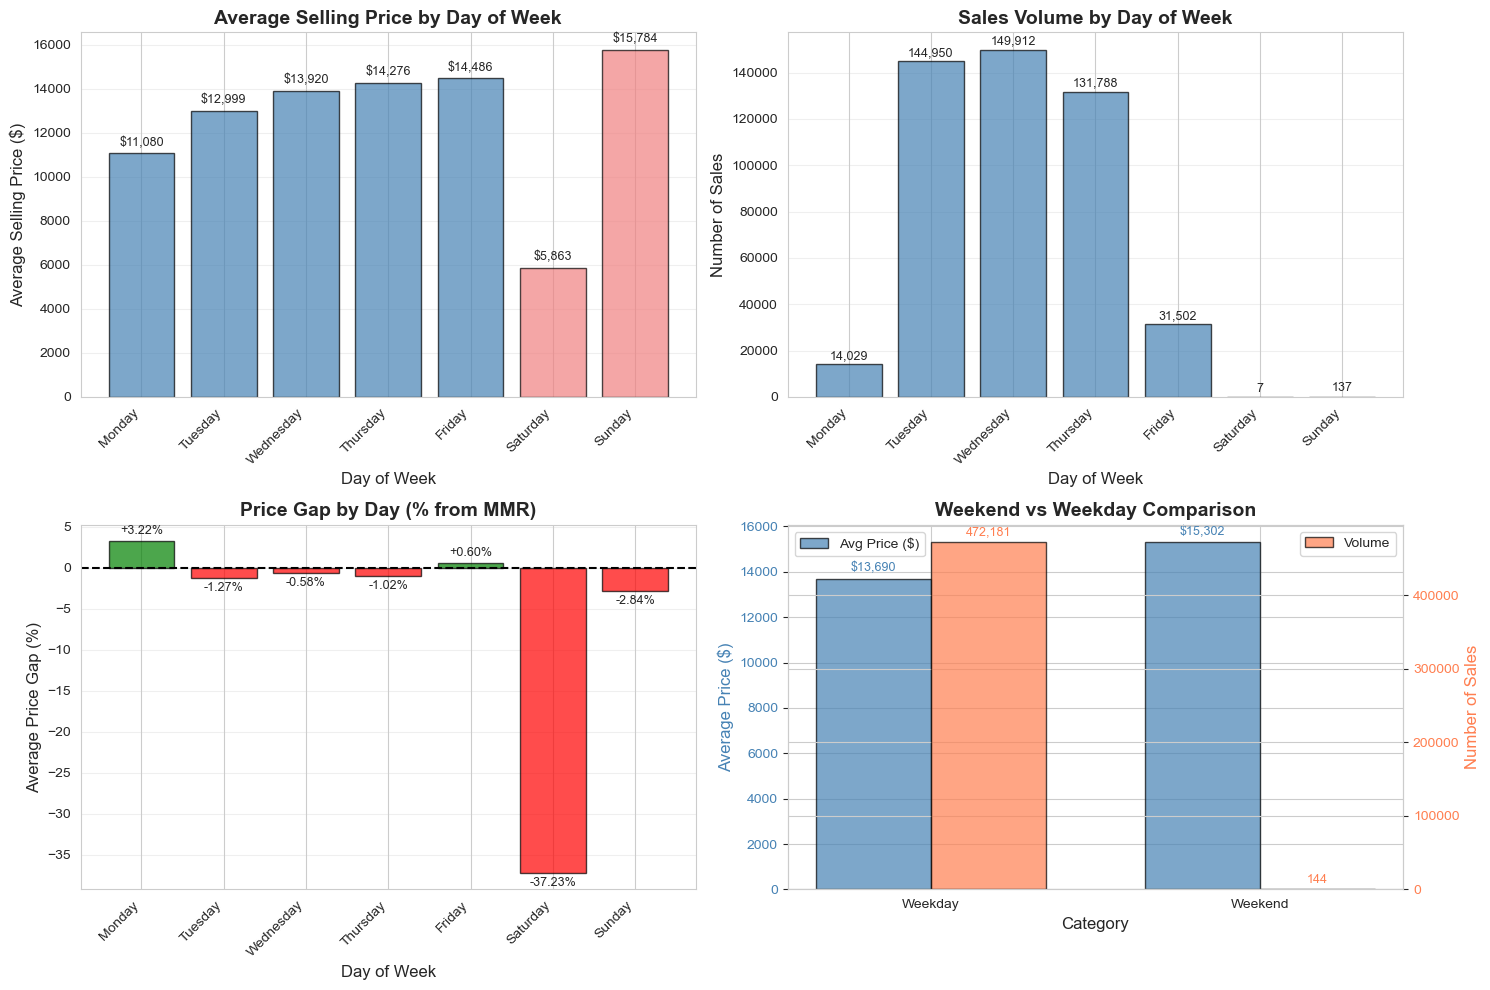

In [8]:
# Visualization: Day of Week Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Filter out days with no data for cleaner visualization
day_stats_plot = day_stats.dropna()
days_available = day_stats_plot.index.tolist()
colors = ['lightcoral' if day in ['Saturday', 'Sunday'] else 'steelblue' for day in days_available]

# Plot 1: Average price by day
axes[0, 0].bar(range(len(days_available)), day_stats_plot['avg_price'], 
               color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Day of Week', fontsize=12)
axes[0, 0].set_ylabel('Average Selling Price ($)', fontsize=12)
axes[0, 0].set_title('Average Selling Price by Day of Week', fontsize=14, fontweight='bold')
axes[0, 0].set_xticks(range(len(days_available)))
axes[0, 0].set_xticklabels(days_available, rotation=45, ha='right')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (day, price) in enumerate(zip(days_available, day_stats_plot['avg_price'])):
    axes[0, 0].text(i, price + 200, f'${price:,.0f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Sales volume by day
axes[0, 1].bar(range(len(days_available)), day_stats_plot['count'], 
               color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Day of Week', fontsize=12)
axes[0, 1].set_ylabel('Number of Sales', fontsize=12)
axes[0, 1].set_title('Sales Volume by Day of Week', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(range(len(days_available)))
axes[0, 1].set_xticklabels(days_available, rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (day, count) in enumerate(zip(days_available, day_stats_plot['count'])):
    axes[0, 1].text(i, count + 1000, f'{count:,.0f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Price gap % by day
gap_colors = ['green' if gap > 0 else 'red' for gap in day_stats_plot['avg_gap_pct']]
axes[1, 0].bar(range(len(days_available)), day_stats_plot['avg_gap_pct'], 
               color=gap_colors, alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel('Day of Week', fontsize=12)
axes[1, 0].set_ylabel('Average Price Gap (%)', fontsize=12)
axes[1, 0].set_title('Price Gap by Day (% from MMR)', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(range(len(days_available)))
axes[1, 0].set_xticklabels(days_available, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (day, gap) in enumerate(zip(days_available, day_stats_plot['avg_gap_pct'])):
    axes[1, 0].text(i, gap + 0.5 if gap > 0 else gap - 0.5, f'{gap:+.2f}%', 
                    ha='center', va='bottom' if gap > 0 else 'top', fontsize=9)

# Plot 4: Weekend vs Weekday comparison
categories = ['Weekday', 'Weekend']
avg_prices = [weekend_comparison.loc['Weekday', 'avg_price'], 
              weekend_comparison.loc['Weekend', 'avg_price']]
counts = [weekend_comparison.loc['Weekday', 'count'], 
          weekend_comparison.loc['Weekend', 'count']]

x = np.arange(len(categories))
width = 0.35

bars1 = axes[1, 1].bar(x - width/2, avg_prices, width, label='Avg Price ($)', 
                       color='steelblue', alpha=0.7, edgecolor='black')
ax2 = axes[1, 1].twinx()
bars2 = ax2.bar(x + width/2, counts, width, label='Volume', 
                color='coral', alpha=0.7, edgecolor='black')

axes[1, 1].set_xlabel('Category', fontsize=12)
axes[1, 1].set_ylabel('Average Price ($)', fontsize=12, color='steelblue')
ax2.set_ylabel('Number of Sales', fontsize=12, color='coral')
axes[1, 1].set_title('Weekend vs Weekday Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(categories)
axes[1, 1].tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='coral')

# Add value labels
for i, price in enumerate(avg_prices):
    axes[1, 1].text(i - width/2, price + 200, f'${price:,.0f}', 
                   ha='center', va='bottom', fontsize=9, color='steelblue')
for i, count in enumerate(counts):
    ax2.text(i + width/2, count + 5000, f'{count:,.0f}', 
            ha='center', va='bottom', fontsize=9, color='coral')

# Add legends
axes[1, 1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [9]:
# ============================================================================
# 1.4: HOUR-OF-DAY ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("1.4: HOUR-OF-DAY PRICING PATTERNS")
print("="*70)

# Calculate statistics by hour
hour_stats = df.groupby('sale_hour').agg({
    'sellingprice': ['mean', 'median', 'count'],
    'price_gap_pct': 'mean'
}).round(2)

hour_stats.columns = ['avg_price', 'median_price', 'count', 'avg_gap_pct']
hour_stats = hour_stats.sort_index()

print("\nTop 5 hours by average selling price:")
print(hour_stats.nlargest(5, 'avg_price')[['avg_price', 'count', 'avg_gap_pct']])

print("\nBottom 5 hours by average selling price:")
print(hour_stats.nsmallest(5, 'avg_price')[['avg_price', 'count', 'avg_gap_pct']])

# Check if hour patterns are significant
hour_variance = hour_stats['avg_price'].std()
overall_avg = df['sellingprice'].mean()
coef_var = (hour_variance / overall_avg) * 100

print(f"\nSTATISTICAL SIGNIFICANCE CHECK:")
print(f"   Overall average price: ${overall_avg:,.2f}")
print(f"   Hour-to-hour std dev:  ${hour_variance:,.2f}")
print(f"   Coefficient of var:    {coef_var:.2f}%")

if coef_var < 5:
    print(f"   → Hour-of-day has minimak impact on pricing (<5% variation)")
else:
    print(f"   → Hour-of-day shows notable impact on pricing (≥5% variation)")
    print(f"   → Consider including as a feature")

# Identify peak and off-peak hours
peak_hours = hour_stats.nlargest(3, 'count')
print(f"\nHigh sales volume hours:")
for hour, row in peak_hours.iterrows():
    print(f"   {int(hour):02d}:00 - {row['count']:.0f} sales (${row['avg_price']:,.0f} avg, {row['avg_gap_pct']:+.2f}% gap)")

# Low volume hours
low_volume_hours = hour_stats[hour_stats['count'] < 1000]
if len(low_volume_hours) > 0:
    print(f"\n  Low volume hours (< 1,000 sales):")
    for hour in low_volume_hours.index:
        print(f"   {int(hour):02d}:00 - {hour_stats.loc[hour, 'count']:.0f} sales")


1.4: HOUR-OF-DAY PRICING PATTERNS

Top 5 hours by average selling price:
           avg_price  count  avg_gap_pct
sale_hour                               
20          19625.00      2        -6.82
14          18608.47   2206        -0.46
4           14648.92  58174         1.38
6           14329.43   7855         0.85
3           14298.12  62542        -0.78

Bottom 5 hours by average selling price:
           avg_price  count  avg_gap_pct
sale_hour                               
19           2500.00      1       -59.35
18           2678.03    611        -8.48
8            8389.05   3495        -1.16
13           8728.37   3055        -2.92
0            9203.89   1418       -11.21

STATISTICAL SIGNIFICANCE CHECK:
   Overall average price: $13,690.51
   Hour-to-hour std dev:  $4,204.38
   Coefficient of var:    30.71%
   → Hour-of-day shows notable impact on pricing (≥5% variation)
   → Consider including as a feature

High sales volume hours:
   02:00 - 126986 sales ($14,229 avg, -0.73

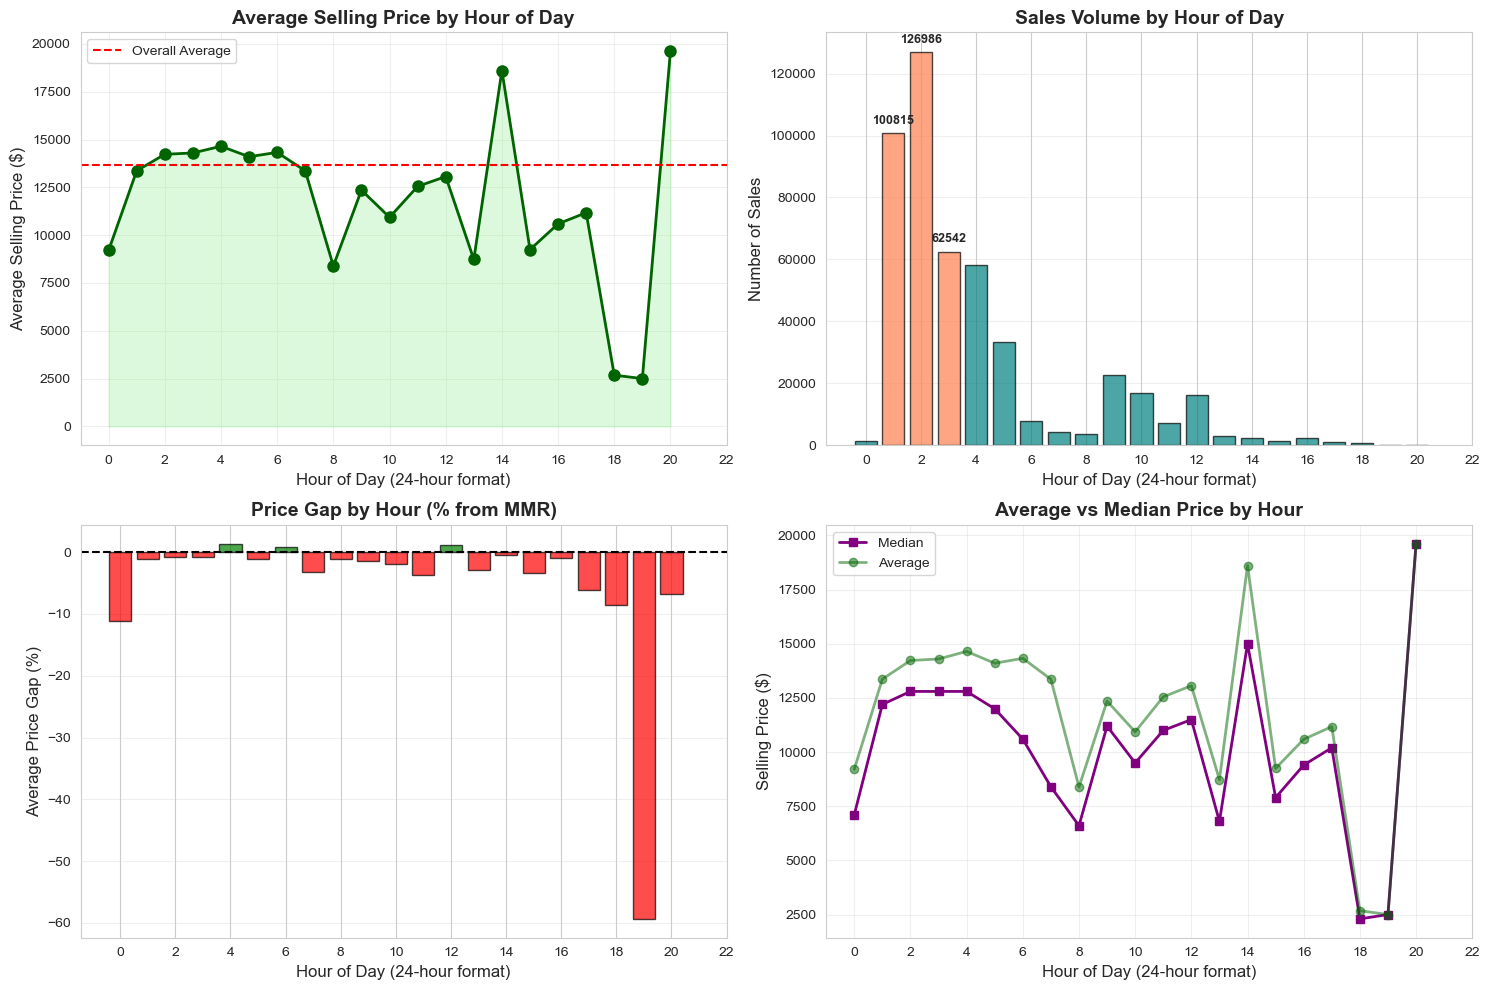

In [10]:
# Visualization: Hour of Day Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Average price by hour (line)
axes[0, 0].plot(hour_stats.index, hour_stats['avg_price'], marker='o', linewidth=2, 
                markersize=8, color='darkgreen')
axes[0, 0].fill_between(hour_stats.index, hour_stats['avg_price'], alpha=0.3, color='lightgreen')
axes[0, 0].set_xlabel('Hour of Day (24-hour format)', fontsize=12)
axes[0, 0].set_ylabel('Average Selling Price ($)', fontsize=12)
axes[0, 0].set_title('Average Selling Price by Hour of Day', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].axhline(y=overall_avg, color='red', linestyle='--', linewidth=1.5, label='Overall Average')
axes[0, 0].legend()

# Plot 2: Sales volume by hour (bar)
bar_colors = ['coral' if hour in peak_hours.index else 'teal' for hour in hour_stats.index]
axes[0, 1].bar(hour_stats.index, hour_stats['count'], color=bar_colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Hour of Day (24-hour format)', fontsize=12)
axes[0, 1].set_ylabel('Number of Sales', fontsize=12)
axes[0, 1].set_title('Sales Volume by Hour of Day', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_xticks(range(0, 24, 2))

# Add labels for peak hours
for hour in peak_hours.index:
    count = hour_stats.loc[hour, 'count']
    axes[0, 1].text(hour, count + 2000, f'{count:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Price gap % by hour
gap_colors = ['green' if gap > 0 else 'red' for gap in hour_stats['avg_gap_pct']]
axes[1, 0].bar(hour_stats.index, hour_stats['avg_gap_pct'], color=gap_colors, alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel('Hour of Day (24-hour format)', fontsize=12)
axes[1, 0].set_ylabel('Average Price Gap (%)', fontsize=12)
axes[1, 0].set_title('Price Gap by Hour (% from MMR)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].set_xticks(range(0, 24, 2))

# Plot 4: Median price by hour (to check if outliers affecting avg)
axes[1, 1].plot(hour_stats.index, hour_stats['median_price'], marker='s', linewidth=2, 
                markersize=6, color='purple', label='Median')
axes[1, 1].plot(hour_stats.index, hour_stats['avg_price'], marker='o', linewidth=2, 
                markersize=6, color='darkgreen', alpha=0.5, label='Average')
axes[1, 1].set_xlabel('Hour of Day (24-hour format)', fontsize=12)
axes[1, 1].set_ylabel('Selling Price ($)', fontsize=12)
axes[1, 1].set_title('Average vs Median Price by Hour', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(range(0, 24, 2))
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [11]:
# ============================================================================
# 1.5: MONTHLY ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("1.5: MONTHLY SEASONALITY PATTERNS")
print("="*70)

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

month_stats = df.groupby('sale_month_name').agg({
    'sellingprice': ['mean', 'median', 'count'],
    'price_gap_pct': 'mean'
}).round(2)

month_stats.columns = ['avg_price', 'median_price', 'count', 'avg_gap_pct']
month_stats = month_stats.reindex(month_order)

print("Top 3 months by average selling price:")
top_months = month_stats.nlargest(3, 'avg_price').dropna()
print(top_months[['avg_price', 'count', 'avg_gap_pct']])

print("\nBottom 3 months by average selling price:")
bottom_months = month_stats.nsmallest(3, 'avg_price').dropna()
print(bottom_months[['avg_price', 'count', 'avg_gap_pct']])

# Identify anomalies
month_stats_clean = month_stats.dropna()
best_month = month_stats_clean['avg_price'].idxmax()
worst_month = month_stats_clean['avg_price'].idxmin()
best_gap_month = month_stats_clean['avg_gap_pct'].idxmax()
worst_gap_month = month_stats_clean['avg_gap_pct'].idxmin()

print(f"\nMONTHLY INSIGHTS:")
print(f"   Highest prices:  {best_month} (${month_stats.loc[best_month, 'avg_price']:,.2f}, {month_stats.loc[best_month, 'count']:.0f} sales)")
print(f"   Lowest prices:   {worst_month} (${month_stats.loc[worst_month, 'avg_price']:,.2f}, {month_stats.loc[worst_month, 'count']:.0f} sales)")
print(f"   Price range:     ${month_stats_clean['avg_price'].max() - month_stats_clean['avg_price'].min():,.2f}")
print(f"\n   Best gap month:  {best_gap_month} ({month_stats.loc[best_gap_month, 'avg_gap_pct']:+.2f}%)")
print(f"   Worst gap month: {worst_gap_month} ({month_stats.loc[worst_gap_month, 'avg_gap_pct']:+.2f}%)")

# Check for low volume months (data gaps)
low_volume_months = month_stats_clean[month_stats_clean['count'] < 5000]
if len(low_volume_months) > 0:
    print(f"\nLOW VOLUME MONTHS (< 5,000 sales):")
    for month in low_volume_months.index:
        print(f"   {month}: {month_stats.loc[month, 'count']:.0f} sales")


1.5: MONTHLY SEASONALITY PATTERNS
Top 3 months by average selling price:
                 avg_price    count  avg_gap_pct
sale_month_name                                 
July              16850.78   1111.0         0.26
June              14806.97  85405.0        -0.58
May               13971.01  43636.0        -2.73

Bottom 3 months by average selling price:
                 avg_price     count  avg_gap_pct
sale_month_name                                  
April             10169.25    1246.0       -17.96
December          12697.17   36600.0        -1.69
January           13272.92  121399.0        -1.22

MONTHLY INSIGHTS:
   Highest prices:  July ($16,850.78, 1111 sales)
   Lowest prices:   April ($10,169.25, 1246 sales)
   Price range:     $6,681.53

   Best gap month:  February (+0.40%)
   Worst gap month: April (-17.96%)

LOW VOLUME MONTHS (< 5,000 sales):
   April: 1246 sales
   July: 1111 sales


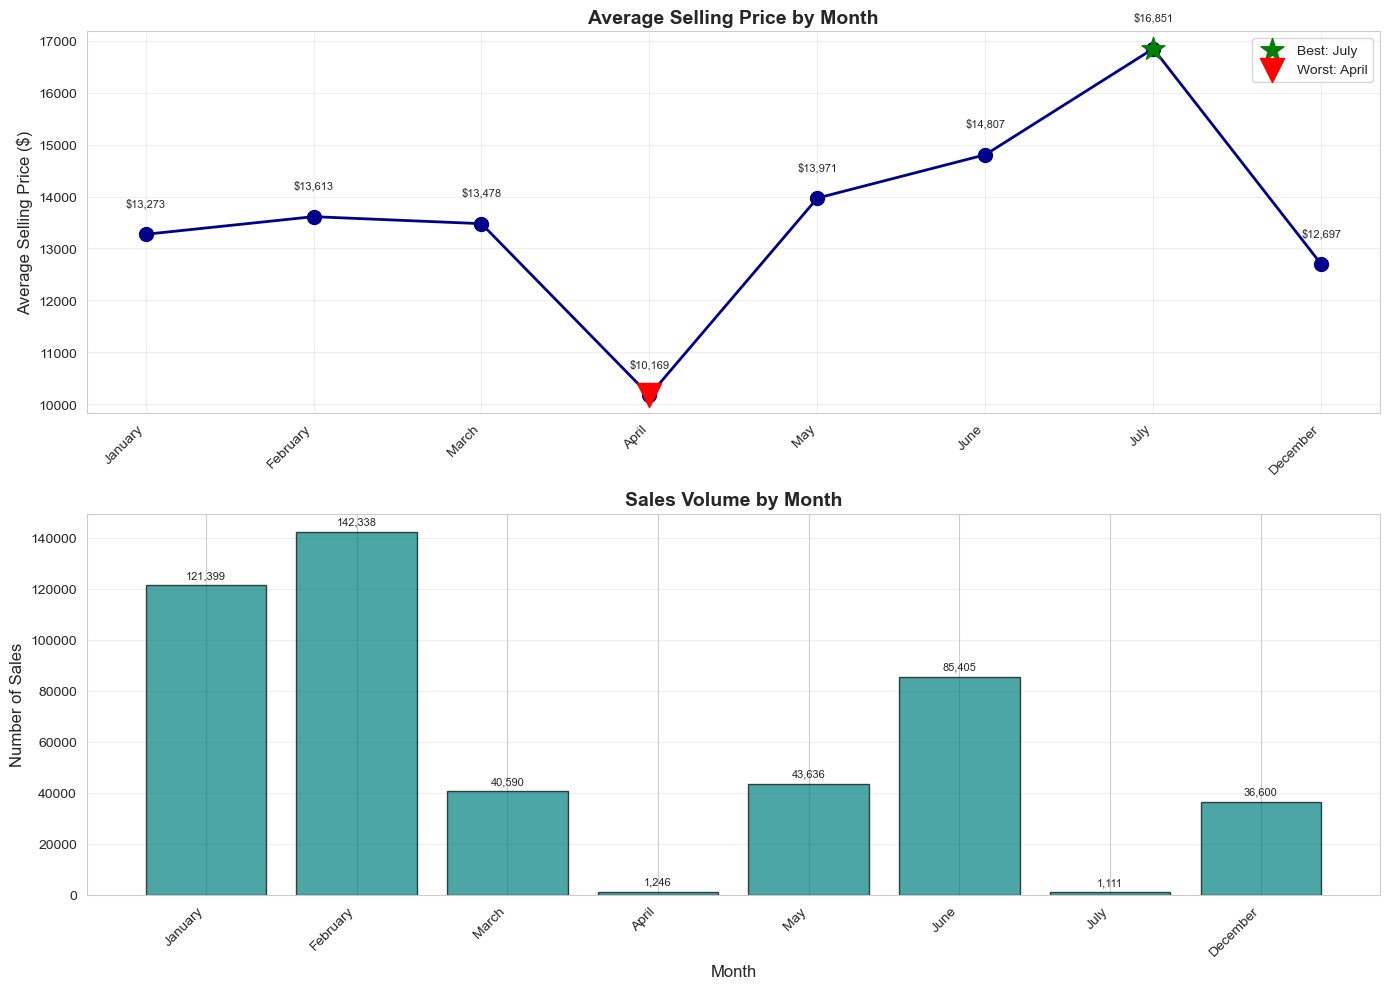

In [12]:
# Visualization: Monthly Patterns
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Filter out months with no data
month_stats_plot = month_stats.dropna()
months_available = month_stats_plot.index.tolist()

# Plot 1: Average price by month
axes[0].plot(range(len(months_available)), month_stats_plot['avg_price'], 
             marker='o', linewidth=2, markersize=10, color='darkblue')
axes[0].set_ylabel('Average Selling Price ($)', fontsize=12)
axes[0].set_title('Average Selling Price by Month', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(months_available)))
axes[0].set_xticklabels(months_available, rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

# Highlight best and worst months
if best_month in months_available and worst_month in months_available:
    best_idx = months_available.index(best_month)
    worst_idx = months_available.index(worst_month)
    axes[0].scatter([best_idx], [month_stats_plot.loc[best_month, 'avg_price']], 
                   color='green', s=300, zorder=5, label=f'Best: {best_month}', marker='*')
    axes[0].scatter([worst_idx], [month_stats_plot.loc[worst_month, 'avg_price']], 
                   color='red', s=300, zorder=5, label=f'Worst: {worst_month}', marker='v')
    axes[0].legend(fontsize=10)

# Add value labels for all months
for i, month in enumerate(months_available):
    price = month_stats_plot.loc[month, 'avg_price']
    axes[0].text(i, price + 500, f'${price:,.0f}', ha='center', va='bottom', 
                fontsize=8, rotation=0)

# Plot 2: Sales volume by month
axes[1].bar(range(len(months_available)), month_stats_plot['count'], 
           color='teal', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Number of Sales', fontsize=12)
axes[1].set_title('Sales Volume by Month', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(months_available)))
axes[1].set_xticklabels(months_available, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (month, count) in enumerate(zip(months_available, month_stats_plot['count'])):
    axes[1].text(i, count + 2000, f'{count:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
# ============================================================================
# SECTION 1 SUMMARY
# ============================================================================

print("\n" + "="*70)
print("SECTION 1 COMPLETE: KEY TEMPORAL INSIGHTS")
print("="*70)

# Gather key metrics
day_stats_clean = day_stats.dropna()
best_day = day_stats_clean['avg_gap_pct'].idxmax()
worst_day = day_stats_clean['avg_gap_pct'].idxmin()
best_day_gap = day_stats_clean['avg_gap_pct'].max()
worst_day_gap = day_stats_clean['avg_gap_pct'].min()

weekend_diff = weekend_comparison.loc['Weekend', 'avg_price'] - weekend_comparison.loc['Weekday', 'avg_price']

month_stats_clean = month_stats.dropna()
price_range = month_stats_clean['avg_price'].max() - month_stats_clean['avg_price'].min()

summary = f"""
DAY-OF-WEEK FINDINGS:
   • Best day:  {best_day} ({best_day_gap:+.2f}% gap)
   • Worst day: {worst_day} ({worst_day_gap:+.2f}% gap)  
   • Saturday anomaly: Only {day_stats.loc['Saturday', 'count']:.0f} sales (-37.23% gap)
   • Weekend vs Weekday: ${weekend_diff:+,.0f} difference

HOUR-OF-DAY FINDINGS:
   • Hour-to-hour variation: {coef_var:.2f}% (significant but likely outlier-driven)
   • Peak volume hours: 02:00, 01:00, 03:00 (overnight sales)
   • Low volume hours: 17:00-20:00 (<1,000 sales)

MONTHLY FINDINGS:
   • Highest prices: {best_month} (${month_stats.loc[best_month, 'avg_price']:,.2f})
   • Lowest prices:  {worst_month} (${month_stats.loc[worst_month, 'avg_price']:,.2f})
   • Price range:    ${price_range:,.2f} ({(price_range/month_stats_clean['avg_price'].mean())*100:.1f}% variation)
   • Best gap:       {best_gap_month} ({month_stats.loc[best_gap_month, 'avg_gap_pct']:+.2f}%)
   • Worst gap:      {worst_gap_month} ({month_stats.loc[worst_gap_month, 'avg_gap_pct']:+.2f}%)

MODELING IMPLICATIONS:
   Strong features: sale_day_of_week, sale_month
   Medium features: is_weekend, sale_quarter
   Weak features: sale_hour (outlier-driven variation)
   
   Recommended approach:
   - Include day_of_week as categorical feature
   - Include month as categorical feature
   - Consider day_of_week × month interaction
   - Flag Saturday sales separately 
   - Exclude  sale_hour (too noisy with low-volume outliers)
"""

print(summary)

print("\n" + "="*70)
print("SECTION 1 COMPLETE!")
print("="*70)


SECTION 1 COMPLETE: KEY TEMPORAL INSIGHTS

DAY-OF-WEEK FINDINGS:
   • Best day:  Monday (+3.22% gap)
   • Worst day: Saturday (-37.23% gap)  
   • Saturday anomaly: Only 7 sales (-37.23% gap)
   • Weekend vs Weekday: $+1,612 difference

HOUR-OF-DAY FINDINGS:
   • Hour-to-hour variation: 30.71% (significant but likely outlier-driven)
   • Peak volume hours: 02:00, 01:00, 03:00 (overnight sales)
   • Low volume hours: 17:00-20:00 (<1,000 sales)

MONTHLY FINDINGS:
   • Highest prices: July ($16,850.78)
   • Lowest prices:  April ($10,169.25)
   • Price range:    $6,681.53 (49.1% variation)
   • Best gap:       February (+0.40%)
   • Worst gap:      April (-17.96%)

MODELING IMPLICATIONS:
   Strong features: sale_day_of_week, sale_month
   Medium features: is_weekend, sale_quarter
   Weak features: sale_hour (outlier-driven variation)
   
   Recommended approach:
   - Include day_of_week as categorical feature
   - Include month as categorical feature
   - Consider day_of_week × month int

---
## Section 2: MMR Gap Analysis 

- Analyzes the gap between MMR (Manheim Market Report - market value) and actual selling price
- Identifies which sellers consistently sell above/below market value
- Looks at state-level variations

In [14]:
# ============================================================================
# 2.1: OVERALL MMR GAP DISTRIBUTION
# ============================================================================

print("="*70)
print("2.1: Overall Price Gap Distribution")
print("="*70)

# Verify price_gap_pct exists
if 'price_gap_pct' not in df.columns:
    df['price_gap_pct'] = (df['price_diff'] / df['mmr']) * 100

# Overall statistics
print("\nPrice Gap (%) Statistics:")
gap_stats = df['price_gap_pct'].describe()
print(gap_stats)

# Categorize by gap performance
df['gap_category'] = pd.cut(df['price_gap_pct'], 
                             bins=[-np.inf, -10, -5, 0, 5, 10, np.inf],
                             labels=['Large Loss (>-10%)', 'Moderate Loss (-10% to -5%)', 
                                    'Small Loss (-5% to 0%)', 'Small Gain (0% to 5%)',
                                    'Moderate Gain (5% to 10%)', 'Large Gain (>10%)'])

gap_distribution = df['gap_category'].value_counts().sort_index()
print("\n" + "-"*70)
print("Sales distribution by price gap category:")
print(gap_distribution)

# Key metrics
pct_above_mmr = (df['price_gap_pct'] > 0).sum() / len(df) * 100
pct_below_mmr = (df['price_gap_pct'] < 0).sum() / len(df) * 100
pct_at_mmr = (df['price_gap_pct'] == 0).sum() / len(df) * 100

print("\nKEY METRICS:")
print(f"   Selling above MMR: {pct_above_mmr:.2f}% ({(df['price_gap_pct'] > 0).sum():,} cars)")
print(f"   Selling below MMR: {pct_below_mmr:.2f}% ({(df['price_gap_pct'] < 0).sum():,} cars)")
print(f"   Selling at MMR:    {pct_at_mmr:.2f}% ({(df['price_gap_pct'] == 0).sum():,} cars)")
print(f"\n   Mean gap:   {df['price_gap_pct'].mean():+.2f}%")
print(f"   Median gap: {df['price_gap_pct'].median():+.2f}%")

2.1: Overall Price Gap Distribution

Price Gap (%) Statistics:
count    472325.000000
mean         -0.723938
std          34.942289
min         -99.995192
25%          -7.258065
50%          -0.367647
75%           5.555556
max        8033.333333
Name: price_gap_pct, dtype: float64

----------------------------------------------------------------------
Sales distribution by price gap category:
gap_category
Large Loss (>-10%)              94858
Moderate Loss (-10% to -5%)     49916
Small Loss (-5% to 0%)         105139
Small Gain (0% to 5%)           96476
Moderate Gain (5% to 10%)       53046
Large Gain (>10%)               72890
Name: count, dtype: int64

KEY METRICS:
   Selling above MMR: 47.09% (222,412 cars)
   Selling below MMR: 50.88% (240,315 cars)
   Selling at MMR:    2.03% (9,598 cars)

   Mean gap:   -0.72%
   Median gap: -0.37%


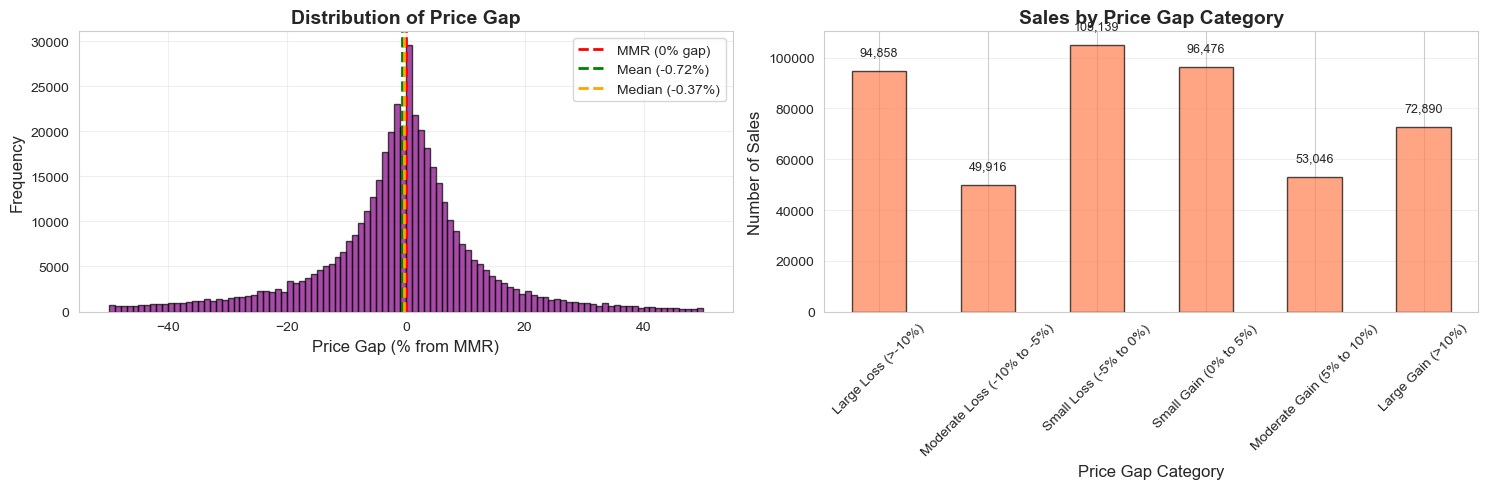

In [15]:
# Visualization: Overall Gap Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Histogram of price gap %
axes[0].hist(df['price_gap_pct'], bins=100, color='purple', alpha=0.7, edgecolor='black', range=(-50, 50))
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='MMR (0% gap)')
axes[0].axvline(x=df['price_gap_pct'].mean(), color='green', linestyle='--', linewidth=2, 
                label=f'Mean ({df["price_gap_pct"].mean():.2f}%)')
axes[0].axvline(x=df['price_gap_pct'].median(), color='orange', linestyle='--', linewidth=2, 
                label=f'Median ({df["price_gap_pct"].median():.2f}%)')
axes[0].set_xlabel('Price Gap (% from MMR)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Price Gap', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Category breakdown
gap_distribution.plot(kind='bar', ax=axes[1], color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Price Gap Category', fontsize=12)
axes[1].set_ylabel('Number of Sales', fontsize=12)
axes[1].set_title('Sales by Price Gap Category', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (cat, count) in enumerate(gap_distribution.items()):
    axes[1].text(i, count + 5000, f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
# ============================================================================
# 2.2: SELLER PERFORMANCE ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("2.2: Seller Performance")
print("="*70)

# Filter sellers with at least 100 sales for meaningful analysis
seller_stats = df.groupby('seller').agg({
    'price_gap_pct': ['mean', 'median'],
    'sellingprice': 'mean',
    'make': 'count'
}).round(2)

seller_stats.columns = ['avg_gap_pct', 'median_gap_pct', 'avg_price', 'num_sales']
seller_stats = seller_stats[seller_stats['num_sales'] >= 100]
seller_stats = seller_stats.sort_values('avg_gap_pct', ascending=False)

print(f"\nAnalyzing {len(seller_stats)} sellers with 100+ sales\n")

print("=" * 70)
print("TOP 10 SELLERS (Highest % Above MMR):")
print("=" * 70)
print(seller_stats.head(10))

print("\n" + "=" * 70)
print("BOTTOM 10 SELLERS (Highest % Below MMR):")
print("=" * 70)
print(seller_stats.tail(10))

# Identify seller types
print("\nSELLER INSIGHTS:")
top_seller = seller_stats.index[0]
bottom_seller = seller_stats.index[-1]
print(f"   Best performer:  {top_seller}")
print(f"     Gap: {seller_stats.loc[top_seller, 'avg_gap_pct']:+.2f}% ({seller_stats.loc[top_seller, 'num_sales']:.0f} sales)")
print(f"\n   Worst performer: {bottom_seller}")
print(f"     Gap: {seller_stats.loc[bottom_seller, 'avg_gap_pct']:+.2f}% ({seller_stats.loc[bottom_seller, 'num_sales']:.0f} sales)")


2.2: Seller Performance

Analyzing 546 sellers with 100+ sales

TOP 10 SELLERS (Highest % Above MMR):
                                 avg_gap_pct  median_gap_pct  avg_price  \
seller                                                                    
crossroads ford of indian trail        44.53           18.42    5956.19   
gwinnett place honda                   38.82           22.22    4731.84   
momentum motorcars                     32.68           13.01   11275.13   
toyota of kirkland                     30.43           21.59   12232.24   
hendrick motors of charlotte           29.58            1.68   11610.29   
honda of concord                       27.63            8.93    3993.08   
courtesy kia of brandon                26.08            0.00    3113.10   
crossroads ford inc                    25.44           16.40    6104.73   
california auto exchange               25.42           18.63    6883.47   
hoehn honda                            24.87           13.00    6278.87 

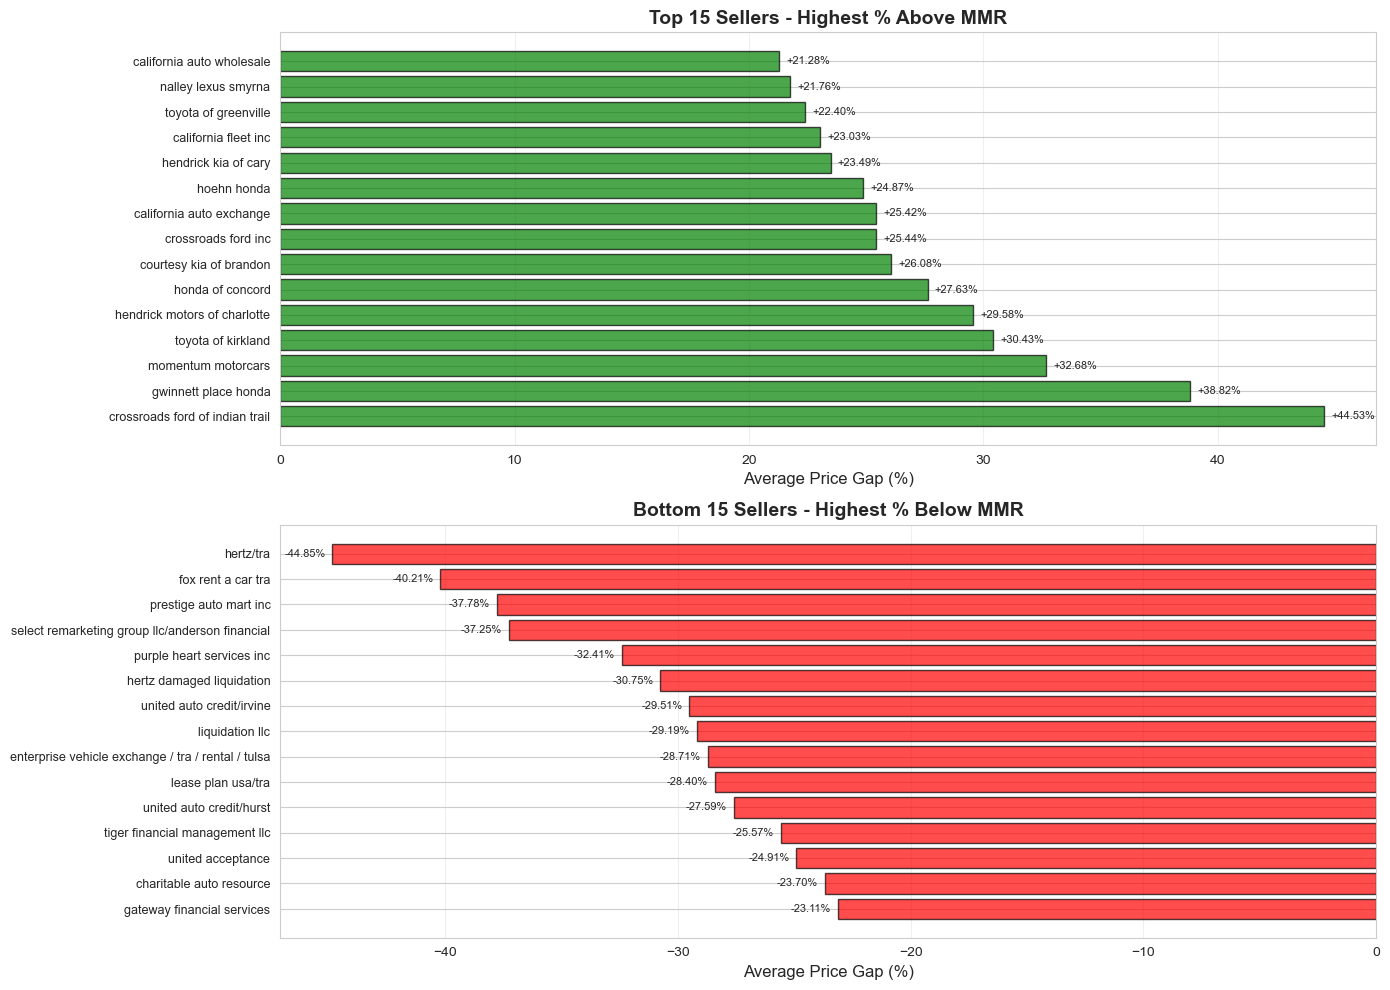

In [17]:
# Visualization: Seller Performance
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Top 15 sellers
top_15 = seller_stats.head(15).sort_values('avg_gap_pct')
axes[0].barh(range(len(top_15)), top_15['avg_gap_pct'], color='green', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15.index, fontsize=9)
axes[0].set_xlabel('Average Price Gap (%)', fontsize=12)
axes[0].set_title('Top 15 Sellers - Highest % Above MMR', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Add value labels
for i, (seller, gap) in enumerate(zip(top_15.index, top_15['avg_gap_pct'])):
    axes[0].text(gap + 0.3, i, f'{gap:+.2f}%', ha='left', va='center', fontsize=8)

# Plot 2: Bottom 15 sellers
bottom_15 = seller_stats.tail(15).sort_values('avg_gap_pct')
axes[1].barh(range(len(bottom_15)), bottom_15['avg_gap_pct'], color='red', alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(bottom_15)))
axes[1].set_yticklabels(bottom_15.index, fontsize=9)
axes[1].set_xlabel('Average Price Gap (%)', fontsize=12)
axes[1].set_title('Bottom 15 Sellers - Highest % Below MMR', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

# Add value labels
for i, (seller, gap) in enumerate(zip(bottom_15.index, bottom_15['avg_gap_pct'])):
    axes[1].text(gap - 0.3, i, f'{gap:+.2f}%', ha='right', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [18]:
# ============================================================================
# 2.3: STATE-LEVEL PRICING VARIATIONS
# ============================================================================

print("\n" + "="*70)
print("2.3: State-Level Analysis")
print("="*70)

# Calculate state-level statistics (filter states with 500+ sales)
state_stats = df.groupby('state').agg({
    'price_gap_pct': 'mean',
    'sellingprice': 'mean',
    'make': 'count'
}).round(2)

state_stats.columns = ['avg_gap_pct', 'avg_price', 'num_sales']
state_stats = state_stats[state_stats['num_sales'] >= 500]
state_stats = state_stats.sort_values('avg_gap_pct', ascending=False)

print(f"\nAnalyzing {len(state_stats)} states with 500+ sales\n")

print("Top 10 states (highest % above MMR):")
print(state_stats.head(10))

print("\nBottom 10 states (highest % below MMR):")
print(state_stats.tail(10))

# Geographic insights
print("\n STATE-LEVEL INSIGHTS:")
best_state = state_stats.index[0]
worst_state = state_stats.index[-1]
print(f"   Best pricing state:  {best_state.upper()} ({state_stats.loc[best_state, 'avg_gap_pct']:+.2f}%)")
print(f"   Worst pricing state: {worst_state.upper()} ({state_stats.loc[worst_state, 'avg_gap_pct']:+.2f}%)")
print(f"   State gap range:     {state_stats['avg_gap_pct'].max() - state_stats['avg_gap_pct'].min():.2f}%")


2.3: State-Level Analysis

Analyzing 31 states with 500+ sales

Top 10 states (highest % above MMR):
       avg_gap_pct  avg_price  num_sales
state                                   
nc            5.95    8696.68      18731
wa            4.64   14327.87       7012
ga            3.50   12840.07      30939
ne            3.18   13242.50       3685
ca            1.77   14895.26      66213
tn            1.34   17285.15      19183
sc            1.10   10747.56       3754
or            0.91   11959.57       1047
co            0.75   15745.50       6270
mo            0.66   14694.78      15286

Bottom 10 states (highest % below MMR):
       avg_gap_pct  avg_price  num_sales
state                                   
wi           -3.93   14105.26       9196
ms           -4.94   11502.42       1730
nj           -4.97   13621.13      23003
in           -5.39   10959.65       3879
pr           -6.25    9755.17       2427
ut           -8.30   12491.60       1716
md           -8.72    7713.60       9

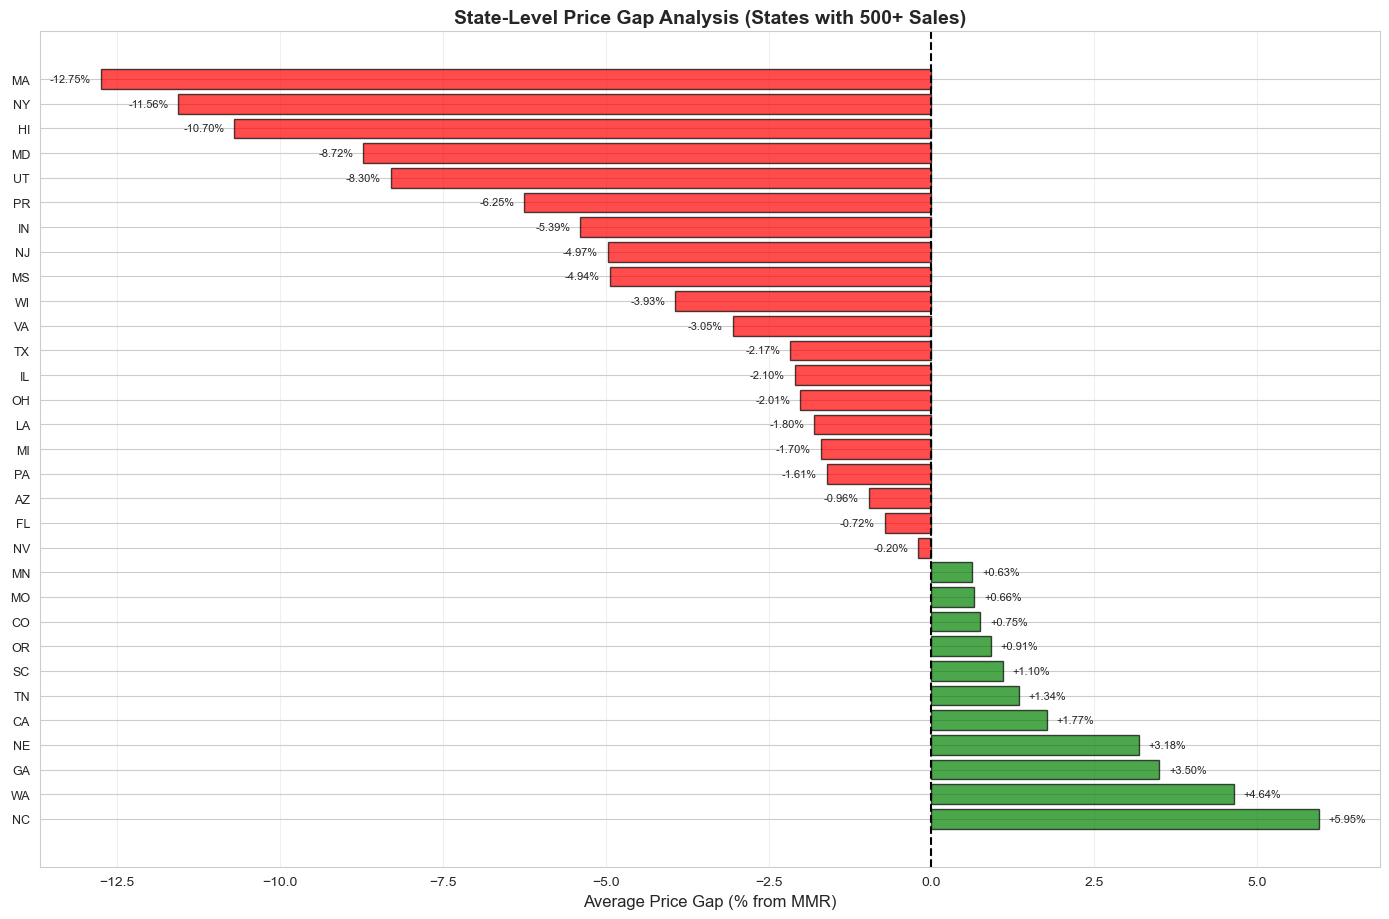

In [19]:
# Visualization: State-Level Pricing 
fig, ax = plt.subplots(figsize=(14, max(8, len(state_stats) * 0.3)))

# Sort by gap percentage
state_stats_sorted = state_stats.sort_values('avg_gap_pct')

# Create colors after sorting, matching the sorted values
colors_sorted = ['green' if x > 0 else 'red' for x in state_stats_sorted['avg_gap_pct']]

ax.barh(range(len(state_stats_sorted)), state_stats_sorted['avg_gap_pct'], 
        color=colors_sorted, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(state_stats_sorted)))
ax.set_yticklabels([s.upper() for s in state_stats_sorted.index], fontsize=9)
ax.set_xlabel('Average Price Gap (% from MMR)', fontsize=12)
ax.set_title('State-Level Price Gap Analysis (States with 500+ Sales)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# Add value labels
for i, (state, gap) in enumerate(zip(state_stats_sorted.index, state_stats_sorted['avg_gap_pct'])):
    label_x = gap + 0.15 if gap > 0 else gap - 0.15
    ha = 'left' if gap > 0 else 'right'
    ax.text(label_x, i, f'{gap:+.2f}%', ha=ha, va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================================
# SECTION 2 SUMMARY
# ============================================================================

print("\n" + "="*70)
print("SECTION 2 COMPLETE: MMR GAP ANALYSIS SUMMARY")
print("="*70)

summary_text = f"""
OVERALL GAP DISTRIBUTION:
   • Mean gap: {df['price_gap_pct'].mean():.2f}% (slightly below market)
   • Median gap: {df['price_gap_pct'].median():.2f}% (even closer to market)
   • Selling above MMR: 47.09% of sales
   • Selling below MMR: 50.88% of sales
   • Selling at MMR: 2.03% of sales
   
   → Most sales cluster near market value (median {df['price_gap_pct'].median():.2f}%)

SELLER PERFORMANCE INSIGHTS:
   Best seller: crossroads ford of indian trail (+44.53% gap)
   Worst seller: hertz/tra (-44.85% gap)
   
   Top performers: Independent dealers
   Bottom performers: Rental companies & liquidation firms
   
   Pattern: 
   - Dealerships sell above market 
   - Rental/lease companies sell below 

GEOGRAPHIC PATTERNS:
   Best state: NC (+5.95% gap)
   Worst state: MA (-12.75% gap)
   State range: 18.70 percentage points
   
   Strong markets: NC, WA, GA, NE (positive gaps)
   Weak markets: MA, NY, HI, MD (>-8% gaps)
   
   CA (largest volume): +1.77% gap, 66,213 sales

MODELING IMPLICATIONS:
   • seller is a strong predictor (44% range from best to worst)
   • state has some meaningful impact (18.7% range)
   • Can consider seller type encoding:
   • Geographic clustering: Consider state or region as feature
   • MMR itself is highly predictive (median gap near 0%)
"""

print(summary_text)

print("="*70)
print("✓ Section 2 complete!")
print("="*70)


SECTION 2 COMPLETE: MMR GAP ANALYSIS SUMMARY

OVERALL GAP DISTRIBUTION:
   • Mean gap: -0.72% (slightly below market)
   • Median gap: -0.37% (even closer to market)
   • Selling above MMR: 47.09% of sales
   • Selling below MMR: 50.88% of sales
   • Selling at MMR: 2.03% of sales
   
   → Most sales cluster near market value (median -0.37%)

SELLER PERFORMANCE INSIGHTS:
   Best seller: crossroads ford of indian trail (+44.53% gap)
   Worst seller: hertz/tra (-44.85% gap)
   
   Top performers: Independent dealers
   Bottom performers: Rental companies & liquidation firms
   
   Pattern: 
   - Dealerships sell above market 
   - Rental/lease companies sell below 

GEOGRAPHIC PATTERNS:
   Best state: NC (+5.95% gap)
   Worst state: MA (-12.75% gap)
   State range: 18.70 percentage points
   
   Strong markets: NC, WA, GA, NE (positive gaps)
   Weak markets: MA, NY, HI, MD (>-8% gaps)
   
   CA (largest volume): +1.77% gap, 66,213 sales

MODELING IMPLICATIONS:
   • seller is a strong pr

---
## Section 3: Luxury Brand Premium Pricing 

- Quantify luxury brand premium and value retention

In [21]:
# ============================================================================
# 3.1: LUXURY BRAND CLASSIFICATION
# ============================================================================

print("="*70)
print("3.1: Defining Luxury Brands")
print("="*70)

# Source: https://www.carsguide.com.au/luxury/advice/luxury-car-brands-from-around-the-world-92882")

# Define luxury brands based on CarsGuide luxury classification
luxury_brands = [
    # German luxury brands (Big 4)
    'BMW', 'Mercedes-Benz', 'Audi', 'Porsche',
    
    # Italian luxury/performance brands
    'Ferrari', 'Maserati', 'Lamborghini', 'Alfa Romeo', 'Pagani',
    
    # British luxury brands
    'Aston Martin', 'Bentley', 'Jaguar', 'Land Rover', 'Rolls-Royce', 'Lotus', 'McLaren',
    
    # Japanese luxury divisions
    'Lexus', 'Infiniti', 'Acura',
    
    # American luxury brands
    'Cadillac', 'Lincoln', 'Tesla', 'Buick',
    
    # Korean luxury
    'Genesis',
    
    # Swedish luxury
    'Volvo', 'Polestar'
]

# Match luxury brands in the dataset (handle variations)
available_makes = df['make'].unique()
luxury_brands_in_data = []

for make in available_makes:
    make_lower = str(make).lower()
    for luxury in luxury_brands:
        # Check for partial matches (e.g., 'Mercedes' matches 'Mercedes-Benz')
        if luxury.lower() in make_lower or make_lower in luxury.lower():
            luxury_brands_in_data.append(make)
            break

print(f"\nDataset contains {len(available_makes)} unique brands")
print(f"Luxury brands identified: {len(luxury_brands_in_data)}")

print(f"\n{'='*70}")
print("Luxury brands in dataset:")
print(f"{'='*70}")
for brand in sorted(luxury_brands_in_data):
    count = (df['make'] == brand).sum()
    print(f"  {brand:20s}: {count:>7,} cars")

# Create luxury classification flags
df['is_luxury'] = df['make'].isin(luxury_brands_in_data).astype(int)

luxury_count = (df['is_luxury'] == 1).sum()
non_luxury_count = (df['is_luxury'] == 0).sum()

print(f"\n{'='*70}")
print("LUXURY CLASSIFICATION SUMMARY")
print(f"{'='*70}")
print(f"Luxury cars:     {luxury_count:>8,} ({luxury_count/len(df)*100:>5.1f}%)")
print(f"Non-Luxury cars: {non_luxury_count:>8,} ({non_luxury_count/len(df)*100:>5.1f}%)")

3.1: Defining Luxury Brands

Dataset contains 53 unique brands
Luxury brands identified: 21

Luxury brands in dataset:
  Acura               :   4,503 cars
  Aston Martin        :      24 cars
  Audi                :   4,802 cars
  BMW                 :  17,509 cars
  Bentley             :     105 cars
  Buick               :   4,470 cars
  Cadillac            :   6,315 cars
  Ferrari             :      17 cars
  Infiniti            :  14,011 cars
  Jaguar              :   1,257 cars
  Lamborghini         :       3 cars
  Land Rover          :   1,322 cars
  Lexus               :  10,409 cars
  Lincoln             :   4,926 cars
  Lotus               :       1 cars
  Maserati            :     109 cars
  Mercedes-Benz       :  14,008 cars
  Porsche             :   1,157 cars
  Rolls-Royce         :      16 cars
  Tesla               :      23 cars
  Volvo               :   3,082 cars

LUXURY CLASSIFICATION SUMMARY
Luxury cars:       88,069 ( 18.6%)
Non-Luxury cars:  384,256 ( 81.4%)


In [22]:
# ============================================================================
# 3.2: LUXURY PREMIUM QUANTIFICATION
# ============================================================================

print("\n" + "="*70)
print("3.2: Quantifying the Luxury Premium")
print("="*70)

# Compare luxury vs non-luxury statistics
luxury_comparison = df.groupby('is_luxury').agg({
    'sellingprice': ['mean', 'median', 'std'],
    'price_gap_pct': 'mean',
    'odometer': 'mean',
    'condition': 'mean',
    'car_age': 'mean',
    'make': 'count'
}).round(2)

luxury_comparison.columns = ['avg_price', 'median_price', 'std_price', 'avg_gap_pct', 
                             'avg_odometer', 'avg_condition', 'avg_age', 'count']

# Rename index for readability
luxury_comparison.index = ['Non-Luxury', 'Luxury']

print("\n" + "="*70)
print("LUXURY VS NON-LUXURY COMPARISON")
print("="*70)
print(luxury_comparison)

# Calculate price premium
luxury_premium = luxury_comparison.loc['Luxury', 'avg_price'] - luxury_comparison.loc['Non-Luxury', 'avg_price']
luxury_premium_pct = (luxury_premium / luxury_comparison.loc['Non-Luxury', 'avg_price']) * 100

print(f"\n{'='*70}")
print("LUXURY PREMIUM:")
print(f"{'='*70}")
print(f"  Absolute: ${luxury_premium:,.0f} more expensive")
print(f"  Relative: {luxury_premium_pct:.1f}% premium over non-luxury")

# Gap comparison (value retention)
luxury_gap = luxury_comparison.loc['Luxury', 'avg_gap_pct']
non_luxury_gap = luxury_comparison.loc['Non-Luxury', 'avg_gap_pct']
gap_difference = luxury_gap - non_luxury_gap

print("\n" + "="*70)
print("VALUE RETENTION (Gap % Analysis):")
print("="*70)
print(f"  Luxury gap:     {luxury_gap:+.2f}% (selling {abs(luxury_gap):.2f}% {'above' if luxury_gap > 0 else 'below'} MMR)")
print(f"  Non-Luxury gap: {non_luxury_gap:+.2f}% (selling {abs(non_luxury_gap):.2f}% below MMR)")
print(f"  Difference:     {gap_difference:+.2f} percentage points")
print(f"\n  → Luxury cars sell {abs(gap_difference):.2f}% closer to market value!")

# Age and mileage
print("\n" + "="*70)
print("AGE & DEPRECIATION:")
print("="*70)
print(f"  Luxury cars age:     {luxury_comparison.loc['Luxury', 'avg_age']:.2f} years")
print(f"  Non-Luxury cars age: {luxury_comparison.loc['Non-Luxury', 'avg_age']:.2f} years")
print(f"  Age difference:            {luxury_comparison.loc['Luxury', 'avg_age'] - luxury_comparison.loc['Non-Luxury', 'avg_age']:+.2f} years")
print(f"\n  Luxury mileage:            {luxury_comparison.loc['Luxury', 'avg_odometer']:,.0f} miles")
print(f"  Non-Luxury mileage:        {luxury_comparison.loc['Non-Luxury', 'avg_odometer']:,.0f} miles")


3.2: Quantifying the Luxury Premium

LUXURY VS NON-LUXURY COMPARISON
            avg_price  median_price  std_price  avg_gap_pct  avg_odometer  \
Non-Luxury   12352.46       11600.0    7777.29        -0.85      66975.85   
Luxury       19528.59       19000.0   13777.02        -0.16      65505.73   

            avg_condition  avg_age   count  
Non-Luxury          30.42     4.53  384256  
Luxury              32.31     5.50   88069  

LUXURY PREMIUM:
  Absolute: $7,176 more expensive
  Relative: 58.1% premium over non-luxury

VALUE RETENTION (Gap % Analysis):
  Luxury gap:     -0.16% (selling 0.16% below MMR)
  Non-Luxury gap: -0.85% (selling 0.85% below MMR)
  Difference:     +0.69 percentage points

  → Luxury cars sell 0.69% closer to market value!

AGE & DEPRECIATION:
  Luxury cars age:     5.50 years
  Non-Luxury cars age: 4.53 years
  Age difference:            +0.97 years

  Luxury mileage:            65,506 miles
  Non-Luxury mileage:        66,976 miles


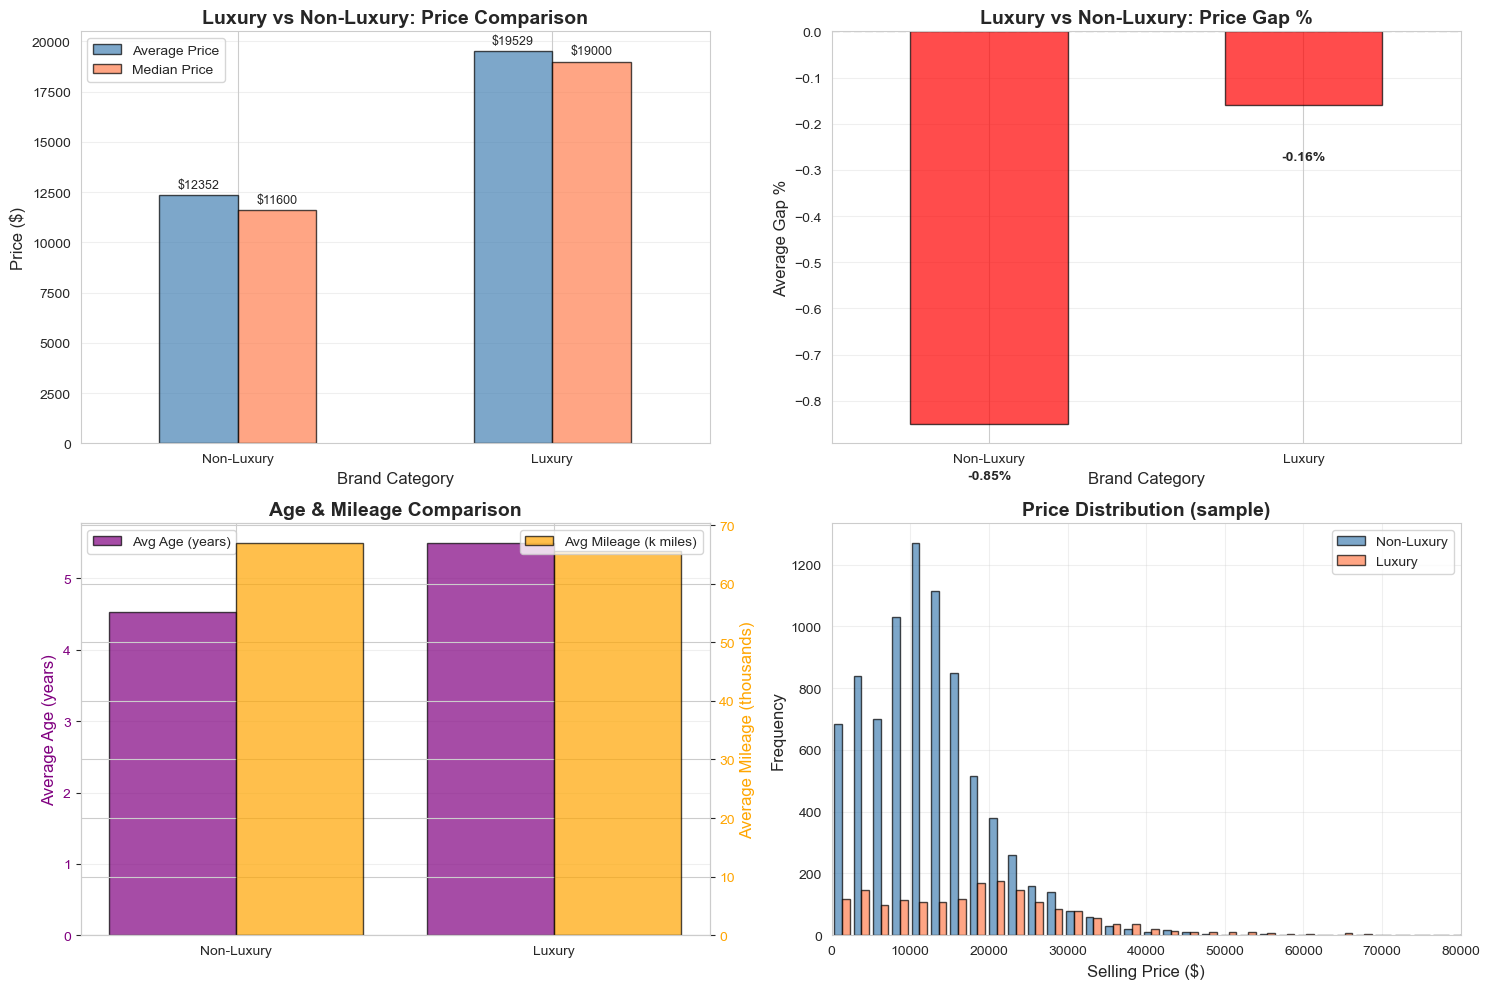

In [23]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Price comparison (avg and median)
luxury_comparison[['avg_price', 'median_price']].plot(kind='bar', ax=axes[0, 0], 
                                                        color=['steelblue', 'coral'], 
                                                        alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Brand Category', fontsize=12)
axes[0, 0].set_ylabel('Price ($)', fontsize=12)
axes[0, 0].set_title('Luxury vs Non-Luxury: Price Comparison', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].legend(['Average Price', 'Median Price'])
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add value labels
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container, fmt='$%.0f', padding=3, fontsize=9)

# Plot 2: Gap % comparison
gap_colors = ['green' if luxury_comparison.loc[cat, 'avg_gap_pct'] >= 0 else 'red' 
              for cat in luxury_comparison.index]
luxury_comparison['avg_gap_pct'].plot(kind='bar', ax=axes[0, 1], 
                                       color=gap_colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Brand Category', fontsize=12)
axes[0, 1].set_ylabel('Average Gap %', fontsize=12)
axes[0, 1].set_title('Luxury vs Non-Luxury: Price Gap %', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (cat, gap) in enumerate(zip(luxury_comparison.index, luxury_comparison['avg_gap_pct'])):
    axes[0, 1].text(i, gap + 0.1 if gap > 0 else gap - 0.1, f'{gap:+.2f}%', 
                   ha='center', va='bottom' if gap > 0 else 'top', fontsize=10, fontweight='bold')

# Plot 3: Age and mileage comparison
x = ['Non-Luxury', 'Luxury']
age_data = [luxury_comparison.loc['Non-Luxury', 'avg_age'], 
            luxury_comparison.loc['Luxury', 'avg_age']]
mileage_data = [luxury_comparison.loc['Non-Luxury', 'avg_odometer'] / 1000, 
                luxury_comparison.loc['Luxury', 'avg_odometer'] / 1000]

x_pos = [0, 1]
bars1 = axes[1, 0].bar([p - 0.2 for p in x_pos], age_data, 0.4, 
                       label='Avg Age (years)', color='purple', alpha=0.7, edgecolor='black')
ax2 = axes[1, 0].twinx()
bars2 = ax2.bar([p + 0.2 for p in x_pos], mileage_data, 0.4, 
                label='Avg Mileage (k miles)', color='orange', alpha=0.7, edgecolor='black')

axes[1, 0].set_ylabel('Average Age (years)', fontsize=12, color='purple')
ax2.set_ylabel('Average Mileage (thousands)', fontsize=12, color='orange')
axes[1, 0].set_title('Age & Mileage Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(x)
axes[1, 0].tick_params(axis='y', labelcolor='purple')
ax2.tick_params(axis='y', labelcolor='orange')
axes[1, 0].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Distribution of selling prices (sample for performance)
sample_size = min(10000, len(df))
sample_df = df.sample(n=sample_size, random_state=42)
luxury_sample = sample_df[sample_df['is_luxury'] == 1]['sellingprice']
non_luxury_sample = sample_df[sample_df['is_luxury'] == 0]['sellingprice']

axes[1, 1].hist([non_luxury_sample, luxury_sample], bins=50, 
                label=['Non-Luxury', 'Luxury'], 
                color=['steelblue', 'coral'], alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Selling Price ($)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].set_title('Price Distribution (sample)', fontsize=14, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 80000)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# ============================================================================
# SECTION 3 SUMMARY
# ============================================================================

print("\n" + "="*70)
print("SECTION 3 COMPLETE: LUXURY BRAND PREMIUM SUMMARY")
print("="*70)

# Calculate key metrics
luxury_premium_abs = luxury_comparison.loc['Luxury', 'avg_price'] - luxury_comparison.loc['Non-Luxury', 'avg_price']
luxury_premium_pct = (luxury_premium_abs / luxury_comparison.loc['Non-Luxury', 'avg_price']) * 100
gap_diff = luxury_comparison.loc['Luxury', 'avg_gap_pct'] - luxury_comparison.loc['Non-Luxury', 'avg_gap_pct']
age_diff = luxury_comparison.loc['Luxury', 'avg_age'] - luxury_comparison.loc['Non-Luxury', 'avg_age']

summary_text = f"""
LUXURY BRAND CLASSIFICATION:
   • Source: CarsGuide luxury brand list
   • Luxury brands identified: 21 (BMW, Mercedes, Audi, Lexus, etc.)
   • Luxury cars in dataset: {luxury_comparison.loc['Luxury', 'count']:,.0f} ({luxury_comparison.loc['Luxury', 'count']/len(df)*100:.1f}%)
   • Top luxury brands: BMW (17.5k), Mercedes (14k), Infiniti (14k), Lexus (10.4k)

LUXURY PREMIUM QUANTIFICATION:
   • Absolute premium: ${luxury_premium_abs:,.0f}
   • Relative premium: {luxury_premium_pct:.1f}%
   • Luxury avg: ${luxury_comparison.loc['Luxury', 'avg_price']:,.0f}
   • Non-Luxury avg: ${luxury_comparison.loc['Non-Luxury', 'avg_price']:,.0f}

VALUE RETENTION (MMR Gap Analysis):
   • Luxury gap: {luxury_comparison.loc['Luxury', 'avg_gap_pct']:+.2f}%
   • Non-Luxury gap: {luxury_comparison.loc['Non-Luxury', 'avg_gap_pct']:+.2f}%
   • Difference: {gap_diff:+.2f} percentage points
   
   → Luxury brands hold value better

AGE & DEPRECIATION:
   • Luxury cars are OLDER: {luxury_comparison.loc['Luxury', 'avg_age']:.2f} years vs {luxury_comparison.loc['Non-Luxury', 'avg_age']:.2f} years
   • Similar mileage: ~{luxury_comparison.loc['Luxury', 'avg_odometer']/1000:.0f}k miles (both categories)
   • Yet luxury still commands 58% premium
   
   → This proves luxury brands depreciate slower than non-luxury

CONDITION & MAINTENANCE:
   • Luxury condition: {luxury_comparison.loc['Luxury', 'avg_condition']:.1f}
   • Non-Luxury condition: {luxury_comparison.loc['Non-Luxury', 'avg_condition']:.1f}
   • Difference: {luxury_comparison.loc['Luxury', 'avg_condition'] - luxury_comparison.loc['Non-Luxury', 'avg_condition']:+.1f} points
   
   → Luxury cars are slightly better maintained

MODELING IMPLICATIONS:
   
   FEATURE ENGINEERING RECOMMENDATIONS:
   • Include: is_luxury (binary: 0/1)
   
   MODELING STRATEGY OPTIONS:
   1. Single model with is_luxury feature 
   2. Separate models for luxury/non-luxury (if interaction effects complex)
   3. Ensemble approach combining both strategies
   
   EXPECTED IMPACT:
   • High feature importance in tree-based models
   • Significant coefficient in linear models
"""

print(summary_text)

print("="*70)
print("Section 3 complete")
print("="*70)


SECTION 3 COMPLETE: LUXURY BRAND PREMIUM SUMMARY

LUXURY BRAND CLASSIFICATION:
   • Source: CarsGuide luxury brand list
   • Luxury brands identified: 21 (BMW, Mercedes, Audi, Lexus, etc.)
   • Luxury cars in dataset: 88,069 (18.6%)
   • Top luxury brands: BMW (17.5k), Mercedes (14k), Infiniti (14k), Lexus (10.4k)

LUXURY PREMIUM QUANTIFICATION:
   • Absolute premium: $7,176
   • Relative premium: 58.1%
   • Luxury avg: $19,529
   • Non-Luxury avg: $12,352

VALUE RETENTION (MMR Gap Analysis):
   • Luxury gap: -0.16%
   • Non-Luxury gap: -0.85%
   • Difference: +0.69 percentage points
   
   → Luxury brands hold value better

AGE & DEPRECIATION:
   • Luxury cars are OLDER: 5.50 years vs 4.53 years
   • Similar mileage: ~66k miles (both categories)
   • Yet luxury still commands 58% premium
   
   → This proves luxury brands depreciate slower than non-luxury

CONDITION & MAINTENANCE:
   • Luxury condition: 32.3
   • Non-Luxury condition: 30.4
   • Difference: +1.9 points
   
   → Luxury

In [29]:
print("\n" + "="*70)
print("SAVING PROCESSED DATAFRAME")
print("="*70)

# Save to CSV with all new features
output_filename = 'car_prices_extended_eda.csv'
df.to_csv(output_filename, index=False)

print(f"  Rows: {len(df):,}")
print(f"  Columns: {len(df.columns)}")

print("\nNew features added in this EDA:")
new_features = ['sale_day_of_week', 'sale_day_name', 'sale_hour', 'is_weekend', 
                'sale_month_name', 'price_gap_pct', 'gap_category', 'is_luxury']
for feature in new_features:
    if feature in df.columns:
        print(f"  ✓ {feature}")



SAVING PROCESSED DATAFRAME
  Rows: 472,325
  Columns: 30

New features added in this EDA:
  ✓ sale_day_of_week
  ✓ sale_day_name
  ✓ sale_hour
  ✓ is_weekend
  ✓ sale_month_name
  ✓ price_gap_pct
  ✓ gap_category
  ✓ is_luxury
